## Geocalibration for ZL048 and ZR048

This notebook would explore using the Kabsch algorithm to solve for $R^r_{r'}$ and $R^m_c$ where we use an iterative approach. 

First we assume we have the rotation $R^r_{r'}$ and use kabsch to solve the following

$$ \min_{R^m_c}  \sum_{i} |(R^r_{r'}R^{r'}_{m,i})^T h^r_i - R^m_c h^c_i| +
|(R^r_{r'}R^{r'}_{m,i})^T v^r_i - R^m_c v^c_i| +
|(R^r_{r'}R^{r'}_{m,i})^T a^r_i - R^m_c a^c_i| $$

Second we assume we have the rotation $R^m_c$ and use kabsch to solve the following

$$ \min_{R^r_{r'}} \sum_{i} |h^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c h^c_i| +
|v^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c v^c_i| +
|a^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c a^c_i|
$$

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import itertools
from tqdm import tqdm
from typing import List

In [3]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

#### Load the data

In [4]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

# outlier removal
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  outlier_removed = True

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	248


In [19]:
def solve_r_mc(data_, rot_rrp):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    hm = (R_rrp @ R_rpm).T @ hr
    m_frame.append(list(hm[:,0]))
    m_frame.append(list(hm[:,1]))
    m_frame.append(list(hm[:,2]))

    # compute hm from hc
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    c_frame.append([fl+b1, b2, cx])
    c_frame.append([0, fl, cy])
    c_frame.append([0, 0, 1])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd


def solve_r_rrp(data_, rot_mc):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    r_frame.append(list(hr[:,0]))
    r_frame.append(list(hr[:,1]))
    r_frame.append(list(hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    hrp = R_rpm @ R_mc @ hc
    rp_frame.append(list(hrp[:,0]))
    rp_frame.append(list(hrp[:,1]))
    rp_frame.append(list(hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

In [20]:
rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
iter, verbose = 1000, 200

for i in range(iter):
  rot_mc, rot_mc_rssd = solve_r_mc(zl, rot_rrp)
  rot_rrp, rot_rrp_rssd = solve_r_rrp(zl, rot_mc)

  if i % verbose == 0:
    print('-'*200)
    print(f"Iteration: {i}")
    print(f"rssd:{rot_mc_rssd:.5f}\t rot_mc: {list(rot_mc.as_quat(canonical=True))}")
    print(f"rssd:{rot_rrp_rssd:.5f}\t rot_rrp: {list(rot_rrp.as_quat(canonical=True))}")



--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Iteration: 0
rssd:342.73515	 rot_mc: [0.4365611046076376, 0.5137700158869952, 0.5564472684531695, 0.48561426065370267]
rssd:342.67744	 rot_rrp: [-0.0001392351969537611, -0.00031869789421519343, 0.0008561807497632057, 0.9999995729997768]
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Iteration: 200
rssd:342.05457	 rot_mc: [0.4369614418459048, 0.512921081790441, 0.5559557332262106, 0.48671334981462977]
rssd:342.05457	 rot_rrp: [-0.000718299683343646, -0.00010842635738543111, 0.00217392605700406, 0.9999973731639442]
------------------------------------------------------------------------------------------------------------------------------

In [5]:
def plot_hr(data_, rot_rrp, rot_mc):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_res(data_, rot_rrp, rot_mc):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle("$H^r$ fit residuals", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_rel_err(data_, rot_rrp, rot_mc):
  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    Hr_compute = R_rrp @ R_rpm @ R_mc @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle("$H^r$ relative errors", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

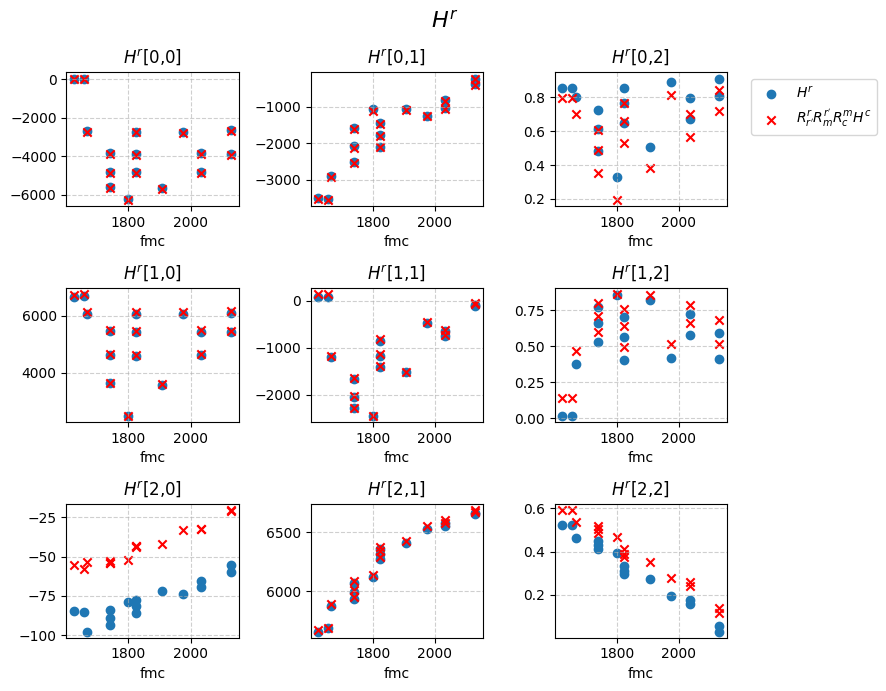

In [22]:
fig, ax = plot_hr(zl, rot_rrp, rot_mc)

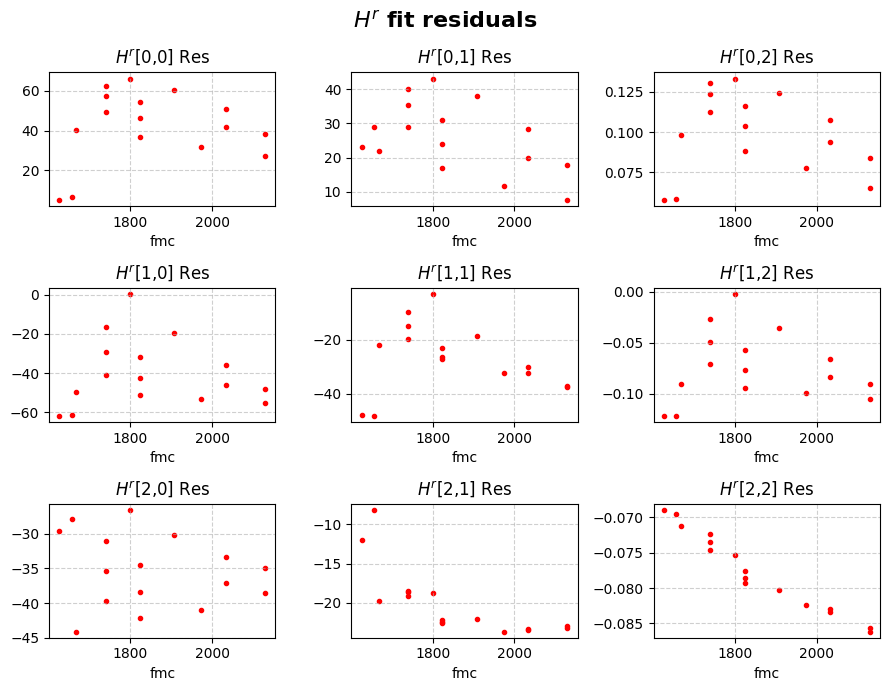

In [23]:
fig, ax = plot_hr_res(zl, rot_rrp, rot_mc)

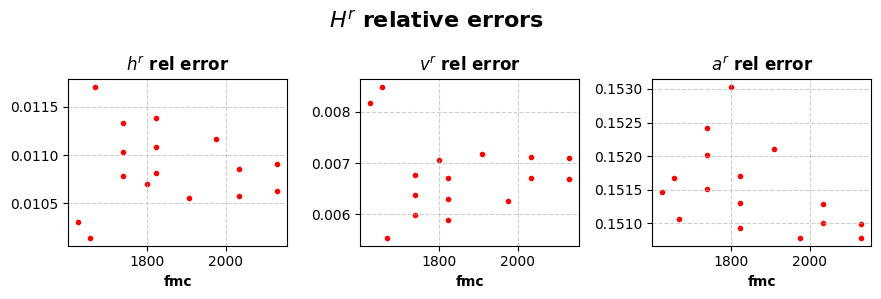

In [24]:
fig, ax = plot_hr_rel_err(zl, rot_rrp, rot_mc)

Here we will instead fit $H^r$ and $H^m$ with scaling factors $\lambda_h$, $\lambda_v$ and $\lambda_a$ fror the vectors $h$, $v$ and $a$.

First we assume we have the rotation $R^r_{r'}$ and use kabsch to solve the following

$$ \min_{R^m_c}  \sum_{i} \lambda_h |(R^r_{r'}R^{r'}_{m,i})^T h^r_i - R^m_c h^c_i| +
\lambda_v |(R^r_{r'}R^{r'}_{m,i})^T v^r_i - R^m_c v^c_i| +
\lambda_a |(R^r_{r'}R^{r'}_{m,i})^T a^r_i - R^m_c a^c_i| $$

Second we assume we have the rotation $R^m_c$ and use kabsch to solve the following

$$ \min_{R^r_{r'}} \sum_{i} \lambda_h |h^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c h^c_i| +
\lambda_v |v^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c v^c_i| +
\lambda_a |a^r_i - R^r_{r'} R^{r'}_{m,i} R^m_c a^c_i|
$$

In [6]:
def solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    scaled_hm = (R_rrp @ R_rpm).T @ hr @ np.diag([lambda_h, lambda_v, lambda_a])
    m_frame.append(list(scaled_hm[:,0]))
    m_frame.append(list(scaled_hm[:,1]))
    m_frame.append(list(scaled_hm[:,2]))

    # compute hm from hc
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
    scaled_hc = hc @ np.diag([lambda_h, lambda_v, lambda_a])
    c_frame.append(scaled_hc[:,0])
    c_frame.append(scaled_hc[:,1])
    c_frame.append(scaled_hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd


def solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    scaled_hr = hr @ np.diag([lambda_h, lambda_v, lambda_a])
    r_frame.append(list(scaled_hr[:,0]))
    r_frame.append(list(scaled_hr[:,1]))
    r_frame.append(list(scaled_hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    scaled_hrp = R_rpm @ R_mc @ hc @ np.diag([lambda_h, lambda_v, lambda_a])
    rp_frame.append(list(scaled_hrp[:,0]))
    rp_frame.append(list(scaled_hrp[:,1]))
    rp_frame.append(list(scaled_hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc):
  # compute the relative error
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

q_rrp_0 = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
iter, verbose = 100, 50

# search space 
lambda_hs = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
lambda_vs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
lambda_as = [1, 2, 3, 4, 5, 6, 7, 8, 9]

# iter through all possible combi of lambda and find the minimum
# errs = []
# for lambda_h, lambda_v, lambda_a in tqdm(itertools.product(lambda_hs, lambda_vs, lambda_as)):
#   # run the iterative fit based on the set of lambdas
#   rot_rrp = R.from_quat(q_rrp_0)
#   for i in range(iter):
#     rot_mc, rot_mc_rssd = solve_r_mc(zl, rot_rrp, lambda_h, lambda_v, lambda_a)
#     rot_rrp, rot_rrp_rssd = solve_r_rrp(zl, rot_mc, lambda_h, lambda_v, lambda_a)
    
#   # calc the relative error 
#   rel_h_err, rel_v_err, rel_a_err = compute_rel_err(zl, rot_rrp, rot_mc)
#   errs.append((lambda_h, lambda_v, lambda_a, rel_h_err + rel_v_err + rel_a_err))


# sorted_errs = sorted(errs, key=lambda x:x[3])
# best_lambda_h, best_lambda_v, best_lambda_a, best_rel_err = sorted_errs[0]
# print(f"lambda_h:{best_lambda_h}, lambda_v:{best_lambda_v}, lambda_a:{best_lambda_a}")

In [7]:
q_rrp_0 = [0, 0, 0, 1]
iter, verbose = 100, 50
lambda_h, lambda_v, lambda_a = 0.01, 0.1, 100

# here we use the best lambdas to redo the fit and plot the results in Hr space
rot_rrp = R.from_quat(q_rrp_0)
for i in range(iter):
  rot_mc, rot_mc_rssd = solve_r_mc(zl, rot_rrp, lambda_h, lambda_v, lambda_a)
  rot_rrp, rot_rrp_rssd = solve_r_rrp(zl, rot_mc, lambda_h, lambda_v, lambda_a)

  if (i+1) % verbose == 0:
    print('-' * 150)
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_rrp={list(rot_rrp.as_quat())}")
  


------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:45.99342	 q_mc=[0.4601740347688341, 0.4929903543907824, 0.535791928828007, 0.5080623753093575]
rot_rrp rssd:45.99342	 q_rrp=[-9.853796594295242e-05, -0.00027816714851900656, 0.002400604249722762, 0.9999970750019936]
------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:45.99340	 q_mc=[0.4601721212466857, 0.49299000642979923, 0.5357632654309186, 0.5080946720862868]
rot_rrp rssd:45.99340	 q_rrp=[-8.554338129412814e-05, -0.00026426793263789204, 0.0024375396336213887, 0.9999969906181339]


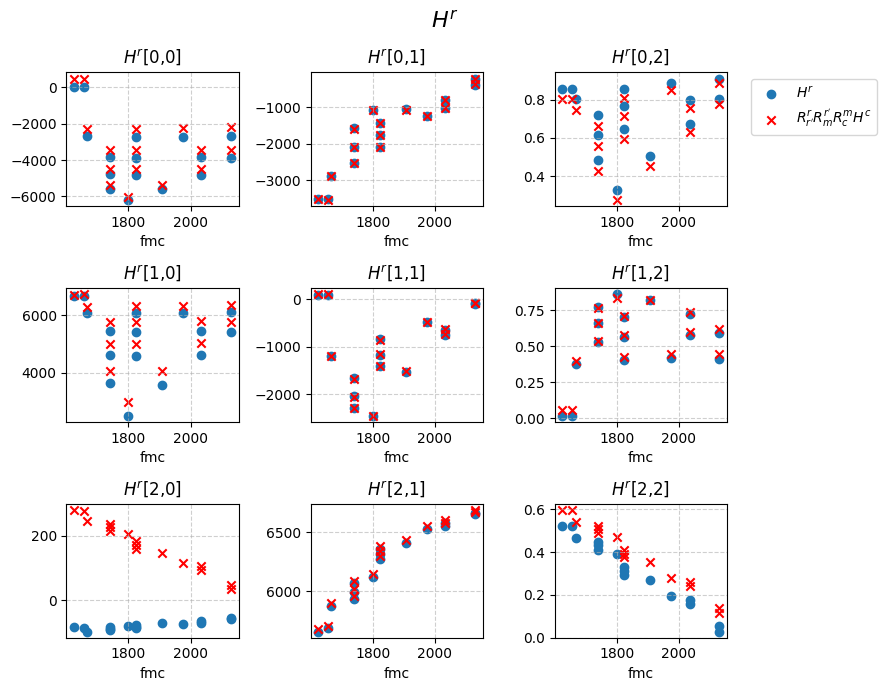

In [8]:
fig, ax = plot_hr(zl, rot_rrp, rot_mc)

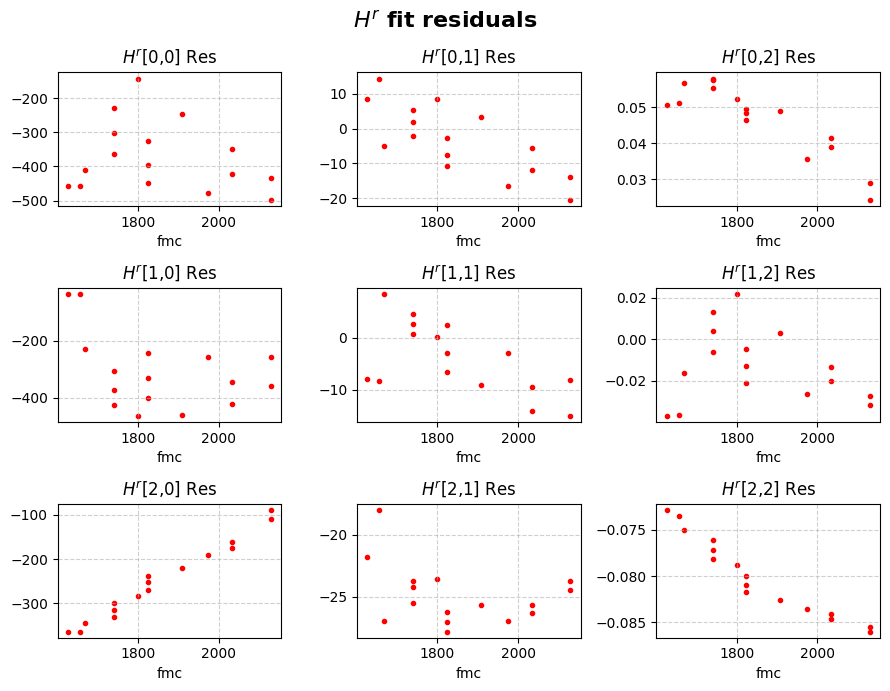

In [9]:
fig, ax = plot_hr_res(zl, rot_rrp, rot_mc)

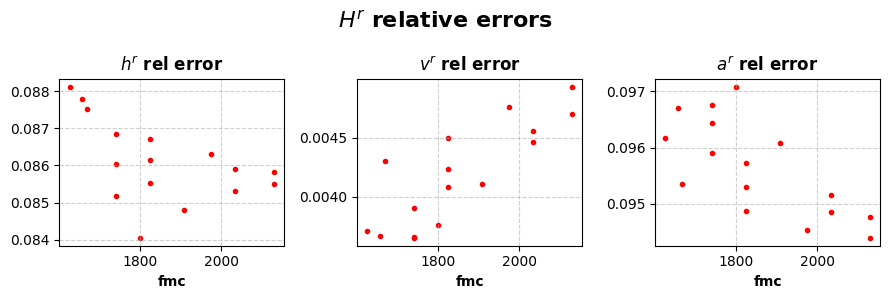

In [10]:
fig, ax = plot_hr_rel_err(zl, rot_rrp, rot_mc)

In [11]:
q_rrp_0 = [0, 0, 0, 1]
iter, verbose = 100, 50
lambda_h, lambda_v, lambda_a = 0.01, 0.1, 100

# here we use the best lambdas to redo the fit and plot the results in Hr space
rot_rrp = R.from_quat(q_rrp_0)
for i in range(iter):
  rot_mc, rot_mc_rssd = solve_r_mc(zr, rot_rrp, lambda_h, lambda_v, lambda_a)
  rot_rrp, rot_rrp_rssd = solve_r_rrp(zr, rot_mc, lambda_h, lambda_v, lambda_a)

  if (i+1) % verbose == 0:
    print('-' * 150)
    print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
    print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_rrp={list(rot_rrp.as_quat())}")
    print(f"Total rel error:{compute_rel_err(zr, rot_rrp, rot_mc)}")

------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:182.42612	 q_mc=[0.47331252617701924, 0.47965457345846224, 0.528388027039165, 0.5164424804428539]
rot_rrp rssd:182.42612	 q_rrp=[0.00039432836510427716, -0.000733844904216233, 0.0018371276647957207, 0.9999979654673004]
Total rel error:(21.437073863974685, 1.1443568567300988, 23.75243585607669)
------------------------------------------------------------------------------------------------------------------------------------------------------
rot_mc rssd:182.42612	 q_mc=[0.4733125261831881, 0.4796545734525553, 0.5283880270252095, 0.516442480456965]
rot_rrp rssd:182.42612	 q_rrp=[0.00039432836552518894, -0.000733844903919762, 0.0018371276802483882, 0.999997965467272]
Total rel error:(21.437073866918784, 1.144356856742968, 23.752435854874182)


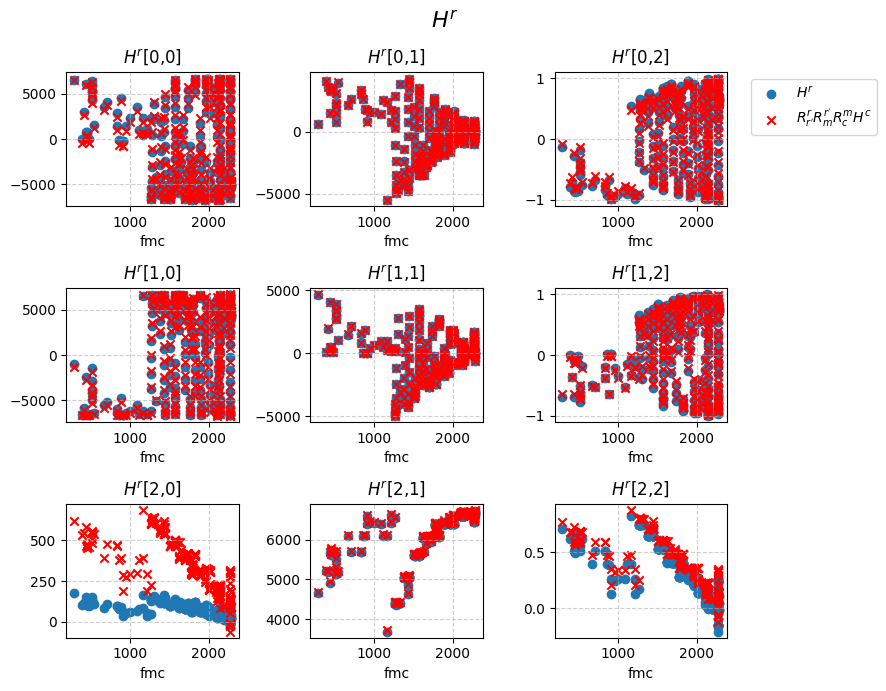

In [111]:
fig, ax = plot_hr(zr, rot_rrp, rot_mc)

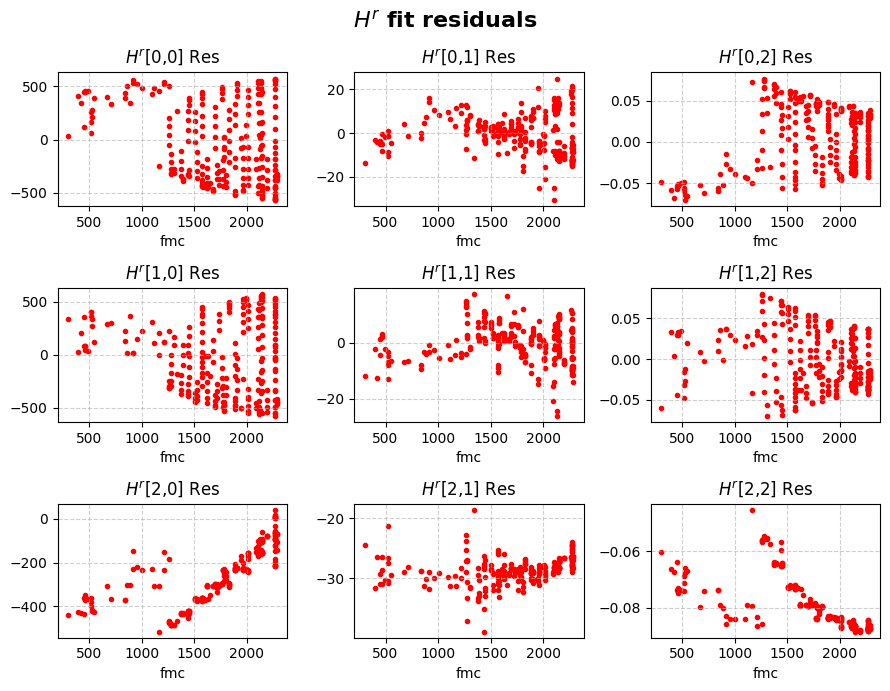

In [112]:
fig, ax = plot_hr_res(zr, rot_rrp, rot_mc)

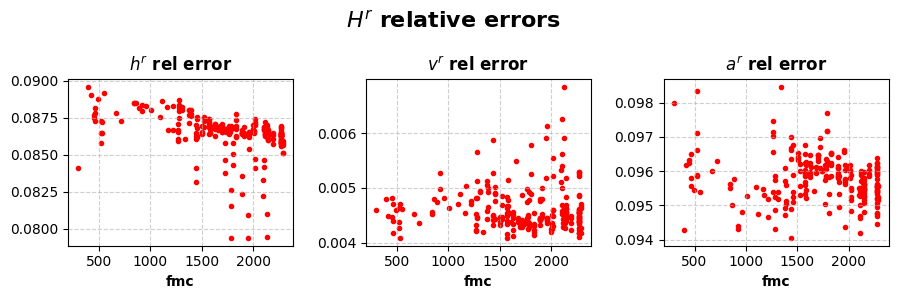

In [113]:
fig, ax = plot_hr_rel_err(zr, rot_rrp, rot_mc)

## Relative error analysis for $q^m_c$ fits

Here we try to understand the relative error of the $h^r$, $v^r$ and $a^r$ vectors when we fit the quaternion $q^m_c$

From previous fits using BFGS we have found

q_mc_zl_0 = [0.44377992, 0.5625695, 0.49968724, 0.48671101]\
q_mc_zl_1 = [-2.32039184e-03, -7.76827219e-04, -1.64998431e-03, 9.99950642e-01]\
q_mc_zr_0 = [0.47604735, 0.4667977, 0.53088594, 0.5231051]\
q_mc_zr_1 = [1.34150488e-03, -2.22995243e-04, 7.61029171e-04, 1.00257474e+00]


In [35]:
def plot_qmc_hr_rel_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_rrp = R.from_quat(q_rrp)
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)

  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hr from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    f = data_["fmc"][i]
    rot_rc = rot_rrp * rot_rpm * (rot_mc_zl_0 * (rot_mc_zl_1**(f/1000)))

    Hr_compute = rot_rc.as_matrix() @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle("$H^r$ relative errors", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_zl_0 * (rot_mc_zl_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

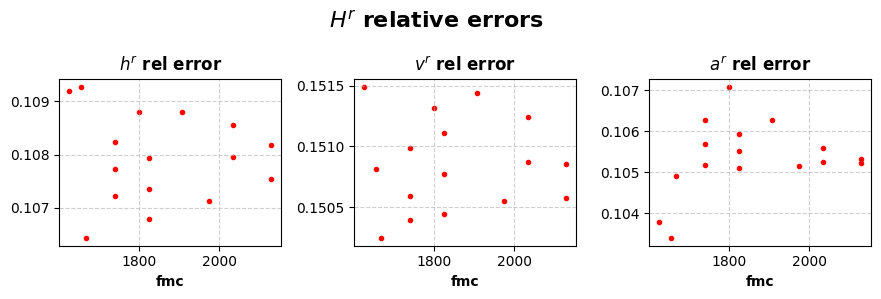

In [36]:
# analysis of the relative error for ZL048 using q_cm
q_mc_zl_0 = [0.44377992, 0.5625695, 0.49968724, 0.48671101]
q_mc_zl_1 = [-2.32039184e-03, -7.76827219e-04, -1.64998431e-03, 9.99950642e-01]
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

plot_qmc_hr_rel_err(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)

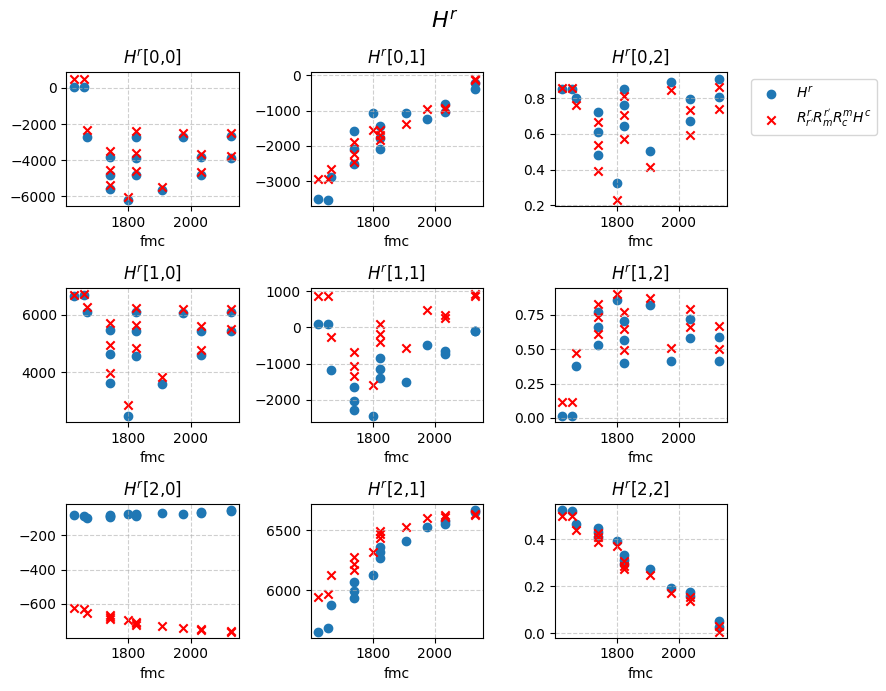

In [37]:
plot_qmc_hr(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)

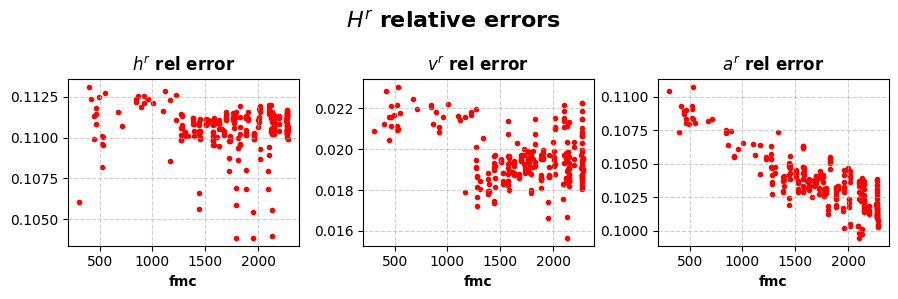

In [38]:
# analysis of the relative error for ZL048 using q_cm
q_mc_zr_0 = [0.47604735, 0.4667977, 0.53088594, 0.5231051]
q_mc_zr_1 = [1.34150488e-03, -2.22995243e-04, 7.61029171e-04, 1.00257474e+00]
q_rrp = [5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]

plot_qmc_hr_rel_err(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)

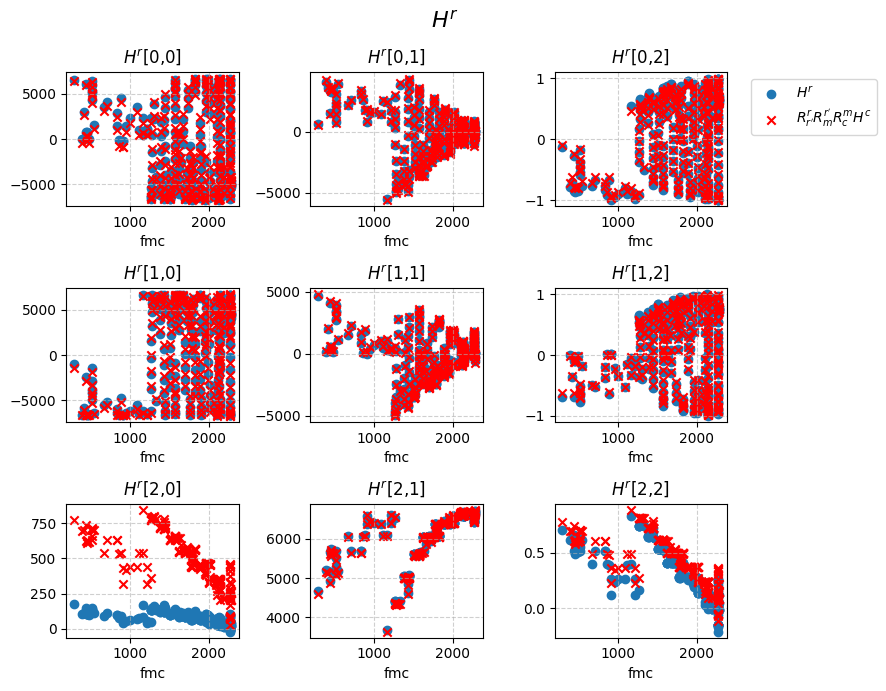

In [39]:
plot_qmc_hr(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)

## BFGS to refine rotations

We will uses the quaternions $q^r_{r'}$ and $q^m_c$ found using the iterative Kabsch algorithm as initial guesses for the quasi-netwon search algorithm BFGS. The objective funciton we consider will be

$$ \min_{q^r_{r'}, q^m_{c,0}, q^m_{c,1}} \sum_{i} d(h^r_i, h^c_i) + d(v^r_i, v^c_i) + d(a^r_i, a^c_i)$$


where 
$$d(x^r, x^c) = \frac{\|x^r - R^r_{r'} R^{r'}_{m} R^m_c x^c\|^2}{\|x^r\|^2}$$
$$R^r_{r'} \leftarrow q^r_{r'}, R^m_c \leftarrow q^m_{c,0}(q^m_{c,1})^{\frac{f}{1000}}$$
and $f$ is the focus motor position




In [65]:
q_rrp = [0.00039432836552518894, -0.000733844903919762, 0.0018371276802483882, 0.999997965467272]
def gen_obj(data_):
  data__ = data_.copy()
  R_rrp = R.from_quat(q_rrp).as_matrix()

  # objective function to minimize over
  def obj(x:List):
    rot_mc_0 = R.from_quat(x[:4])
    rot_mc_1 = R.from_quat(x[4:8])

    total_cost = 0
    for i in range(data__.shape[0]):
      # H^r matrix
      Hr = get_H_r_data(i, data__)

      # H^c matrix
      fl, b1, b2, cx, cy = data__[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
      Hc = [[fl+b1, 0, 0],
            [b2, fl, 0],
            [cx, cy, 1]]
      

      # rotation matrices
      R_rpm = get_R_rpm(i, data__)
      f = data__["fmc"][i]
      R_mc = (rot_mc_0 * (rot_mc_1**(f/1000))).as_matrix()
      

      # Errors
      err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
      total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
      total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
      total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

      return total_cost
  
  return obj

def plot_qmc_hr_rel_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_rrp = R.from_quat(q_rrp)
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)

  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hr from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    rot_rpm = R.from_matrix(get_R_rpm(i, data_))
    f = data_["fmc"][i]
    rot_rc = rot_rrp * rot_rpm * (rot_mc_zl_0 * (rot_mc_zl_1**(f/1000)))

    Hr_compute = rot_rc.as_matrix() @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle("$H^r$ relative errors", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_zl_0 = R.from_quat(q_mc_0)
  rot_mc_zl_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_zl_0 * (rot_mc_zl_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle("$H^r$", fontsize=16, fontweight="bold")
  fig.tight_layout()

In [66]:
left_obj = gen_obj(zl)
x0 = [0.4733125261831881, 0.4796545734525553, 0.5283880270252095, 0.516442480456965,
      0.01, 0.01, 0.01, 1,
      0.01, 0.01, 0.01, 1]
left_res = minimize(left_obj, x0, method="BFGS",
                    options={"gtol":1e-19, "xrtol":1e-19, "maxiter":100})
q_mc_zl_0 = np.array(left_res.x[0:4])/np.linalg.norm(left_res.x[0:4])
q_mc_zl_1 = np.array(left_res.x[4:8])
q_mc_zl_2 = np.array(left_res.x[8:12])

print(f"Left optimization")
print(f"Final function value:\t{left_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(left_res.jac):.6f}")
print(f"q_cm_zl_0:\t\t{list(q_mc_zl_0)}")
print(f"q_cm_zl_1:\t\t{list(q_mc_zl_1)}")
print(f"q_cm_zl_2:\t\t{list(q_mc_zl_2)}")
print('-'*100)

Left optimization
Final function value:	0.011723
Final Jacobian value:	0.000000
q_cm_zl_0:		[0.4703199950211369, 0.48264040470819236, 0.5272551052835185, 0.5175513462246]
q_cm_zl_1:		[0.010399771565122534, 0.014827217184270578, -0.0003038806336043648, 1.0026256125636142]
q_cm_zl_2:		[0.01, 0.01, 0.01, 1.0]
----------------------------------------------------------------------------------------------------


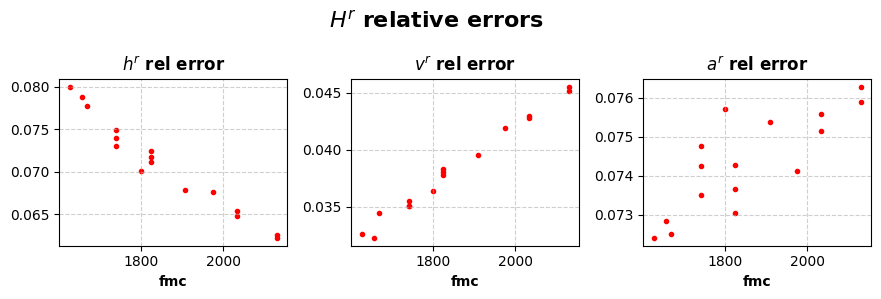

In [68]:
# plot_qmc_hr(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)
# plot_qmc_hr_err(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)
plot_qmc_hr_rel_err(zl, q_rrp, q_mc_zl_0, q_mc_zl_1)

In [69]:
right_obj = gen_obj(zr)
x0 = [0.4733125261831881, 0.4796545734525553, 0.5283880270252095, 0.516442480456965,
      0.01, 0.01, 0.01, 1]
right_res = minimize(right_obj, x0, method="BFGS",
                    options={"gtol":1e-19, "xrtol":1e-19, "maxiter":100})
q_mc_zr_0 = np.array(right_res.x[0:4])/np.linalg.norm(right_res.x[0:4])
q_mc_zr_1 = np.array(right_res.x[4:8])

print(f"Right optimization")
print(f"Final function value:\t{right_res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(right_res.jac):.6f}")
print(f"q_cm_zr_0:\t\t{list(q_mc_zr_0)}")
print(f"q_cm_zr_1:\t\t{list(q_mc_zr_1)}")
print('-'*100)

Right optimization
Final function value:	0.011897
Final Jacobian value:	0.000000
q_cm_zr_0:		[0.4774550841411519, 0.49341353566535207, 0.5222986819208713, 0.505750741288337]
q_cm_zr_1:		[0.015223892553825375, 0.012129308957783675, 0.009402593984249426, 0.9998944441071815]
----------------------------------------------------------------------------------------------------


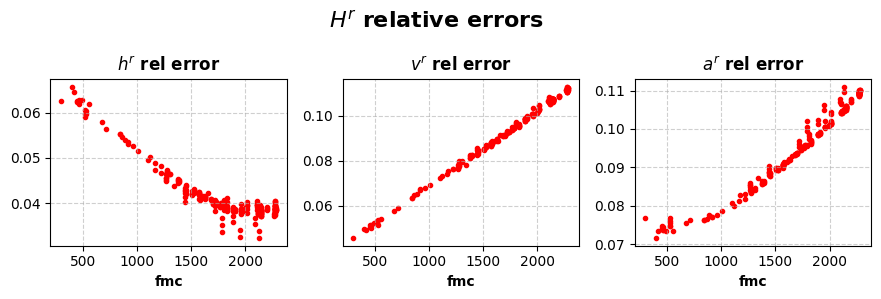

In [70]:
# plot_qmc_hr(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)
# plot_qmc_hr_err(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)
plot_qmc_hr_rel_err(zr, q_rrp, q_mc_zr_0, q_mc_zr_1)